In [ ]:
import json, re
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

PRESOLVER    = "propagation"  
IS_MIP       = False
REGION_RANGE = (None, None)
RES_RANGE    = (None, None)
T_RANGE      = (None, None)
F_RANGE      = (None, None)
CF_VALUES    = None # None or range
DIR_BASE     = Path("/data/energy-system-preprocessing/presolve")

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})

def _cmap(name):
    return cm.get_cmap(name)

KIND_ORDER  = ["Trivial", "Fast", "Medium", "Exhaustive", "Final"]
kind_colors = {k: _cmap("tab10")(i / len(KIND_ORDER)) for i, k in enumerate(KIND_ORDER)}

_ESP_RE = re.compile(r"r(\d+)_res(\d+)_f([\d.]+)_t([\d.]+)(?:_cf([\d.]+))?(_mip)?(_obj)?$")


def _in_range(val, lo, hi):
    if lo is not None and val < lo: return False
    if hi is not None and val > hi: return False
    return True


def _is_target(stem: str) -> bool:
    m = _ESP_RE.match(stem)
    if not m:
        return False
    k      = int(m.group(1))
    res    = int(m.group(2))
    f      = float(m.group(3))
    t      = float(m.group(4))
    cf     = float(m.group(5)) if m.group(5) else None
    is_mip = bool(m.group(6))
    is_obj = bool(m.group(7))
    if IS_MIP and not is_mip:  return False
    if not IS_MIP and is_mip:  return False
    if not is_obj:             return False
    if not _in_range(k,   *REGION_RANGE): return False
    if not _in_range(res, *RES_RANGE):    return False
    if not _in_range(t,   *T_RANGE):      return False
    if not _in_range(f,   *F_RANGE):      return False
    if CF_VALUES is not None and cf not in CF_VALUES: return False
    return True


def parse_name(stem: str) -> dict:
    m = _ESP_RE.match(stem)
    if not m:
        return {"model": stem, "k": None, "res": None, "f": None, "t": None, "cf": None}
    return {
        "model":  stem,
        "k":      int(m.group(1)),
        "res":    int(m.group(2)),
        "f":      float(m.group(3)),
        "t":      float(m.group(4)),
        "cf":     float(m.group(5)) if m.group(5) else None,
        "is_mip": bool(m.group(6)),
    }


def load_dir(root: Path) -> pd.DataFrame:
    rows = []
    for path in sorted(root.glob("*/metadata.json")):
        stem = path.parent.name
        if not _is_target(stem):
            continue
        d   = json.loads(path.read_text())
        p   = d.get("papilo", {})
        tot = p.get("total", {})
        rows.append({
            **parse_name(stem),
            "n_vars":        d.get("n_vars", 0),
            "n_constraints": d.get("n_constraints", 0),
            "nnz":           d.get("nnz", 0),
            "del_cols":      tot.get("del_cols",      0),
            "del_rows":      tot.get("del_rows",      0),
            "chg_bounds":    tot.get("chg_bounds",    0),
            "chg_sides":     tot.get("chg_sides",     0),
            "chg_coeffs":    tot.get("chg_coeffs",    0),
            "tsx_applied":   tot.get("tsx_applied",   0),
            "tsx_conflicts": tot.get("tsx_conflicts", 0),
            "n_rounds":      p.get("n_rounds", 0),
            "rounds":        p.get("rounds", []),
        })
    return pd.DataFrame(rows)


_subdir  = "static_mip" if IS_MIP else "static"
DIR_DATA = DIR_BASE / _subdir / PRESOLVER

assert DIR_DATA.exists(), f"Directory not found: {DIR_DATA}"

df = load_dir(DIR_DATA)

df["del_vars_frac"]   = df["del_cols"]      / df["n_vars"]        .where(df["n_vars"]        > 0, np.nan)
df["del_rows_frac"]   = df["del_rows"]      / df["n_constraints"] .where(df["n_constraints"] > 0, np.nan)
df["chg_bounds_frac"] = df["chg_bounds"]    / df["n_vars"]        .where(df["n_vars"]        > 0, np.nan)
df["chg_coeffs_frac"] = df["chg_coeffs"]    / df["nnz"]           .where(df["nnz"]           > 0, np.nan)
df["conflict_ratio"]  = df["tsx_conflicts"] / df["tsx_applied"]   .where(df["tsx_applied"]   > 0, np.nan)
df = df.fillna(0)

_valid = lambda col: sorted(v for v in df[col].unique() if v is not None and not (isinstance(v, float) and np.isnan(v)))
ks   = _valid("k")
ress = _valid("res")
k_colors = {k: _cmap("tab10")(i / max(len(ks),   1)) for i, k in enumerate(ks)}
r_colors = {r: _cmap("Set2") (i / max(len(ress), 1)) for i, r in enumerate(ress)}

LABEL_PARTS = [f"{PRESOLVER}", "MIP" if IS_MIP else "LP"]
if REGION_RANGE != (None, None): LABEL_PARTS.append(f"k∈{REGION_RANGE}")
if RES_RANGE    != (None, None): LABEL_PARTS.append(f"res∈{RES_RANGE}")
if T_RANGE      != (None, None): LABEL_PARTS.append(f"t∈{T_RANGE}")
if F_RANGE      != (None, None): LABEL_PARTS.append(f"f∈{F_RANGE}")
if CF_VALUES    is not None:     LABEL_PARTS.append(f"cf∈{CF_VALUES}")
LABEL = "  ["+", ".join(LABEL_PARTS)+"]"

print(f"Presolver : {PRESOLVER}")
print(f"MIP       : {IS_MIP}")
print(f"Data dir  : {DIR_DATA}")
print(f"Models    : {len(df)}")
print(f"k={ks}")
print(f"res={ress}")
df[["k", "res", "f", "t", "cf", "n_vars", "del_vars_frac", "del_rows_frac", "chg_coeffs_frac"]].head()

Presolver : propagation
MIP       : False
Data dir  : /data/energy-system-preprocessing/presolve/static/propagation
Models    : 485
k=[np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(9), np.int64(10), np.int64(11), np.int64(13), np.int64(15), np.int64(16), np.int64(17), np.int64(20), np.int64(22), np.int64(23), np.int64(25), np.int64(27), np.int64(29), np.int64(30), np.int64(32), np.int64(34), np.int64(35)]
res=[np.int64(1), np.int64(8), np.int64(24), np.int64(168)]


/tmp/ipykernel_2895790/3522157305.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  return cm.get_cmap(name)
/tmp/ipykernel_2895790/3522157305.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  return cm.get_cmap(name)


,k,res,f,t,cf,n_vars,del_vars_frac,del_rows_frac,chg_coeffs_frac
0,10,168,0.00,0.0192,0.0,213,0.000000,0.202703,0.0
1,10,168,0.00,0.0833,0.0,637,0.000000,0.018797,0.0
2,10,168,0.00,1.0000,0.0,5725,0.000349,0.002335,0.0
3,10,168,0.25,0.5000,0.0,1591,0.001886,0.009312,0.0
4,10,168,0.50,1.0000,0.0,2969,0.000674,0.004539,0.0


## 1 · Elimination fraction heatmaps (k × res)

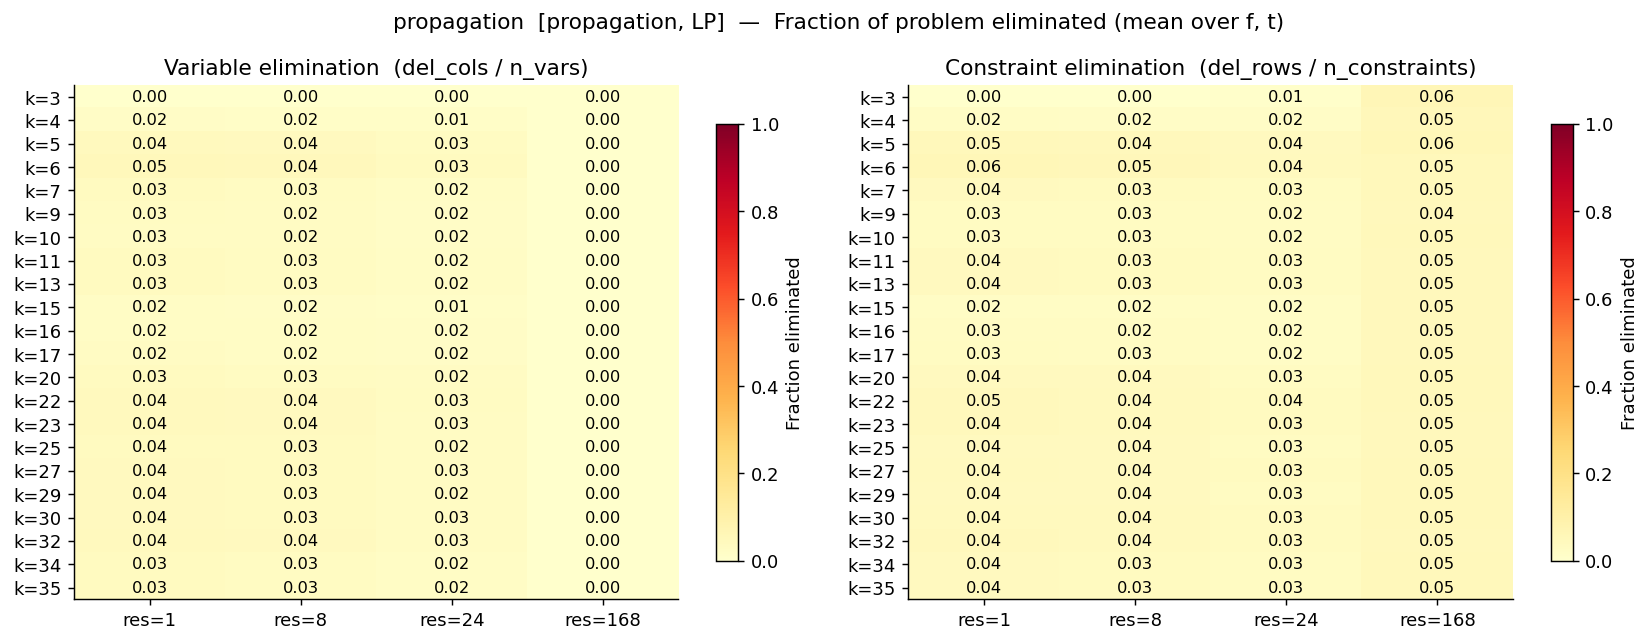

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in [
    (axes[0], "del_vars_frac",  "Variable elimination  (del_cols / n_vars)"),
    (axes[1], "del_rows_frac",  "Constraint elimination  (del_rows / n_constraints)"),
]:
    pivot = df.groupby(["k", "res"])[col].mean().unstack("res")
    im = ax.imshow(pivot.values, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"res={r}" for r in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"k={k}" for k in pivot.index])
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            v = pivot.values[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9,
                    color="white" if v > 0.6 else "black")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.85, label="Fraction eliminated")

fig.suptitle(f"{PRESOLVER}{LABEL}  —  Fraction of problem eliminated (mean over f, t)", fontsize=12)
fig.tight_layout()
plt.show()

## 2 · Elimination fraction vs k, by resolution

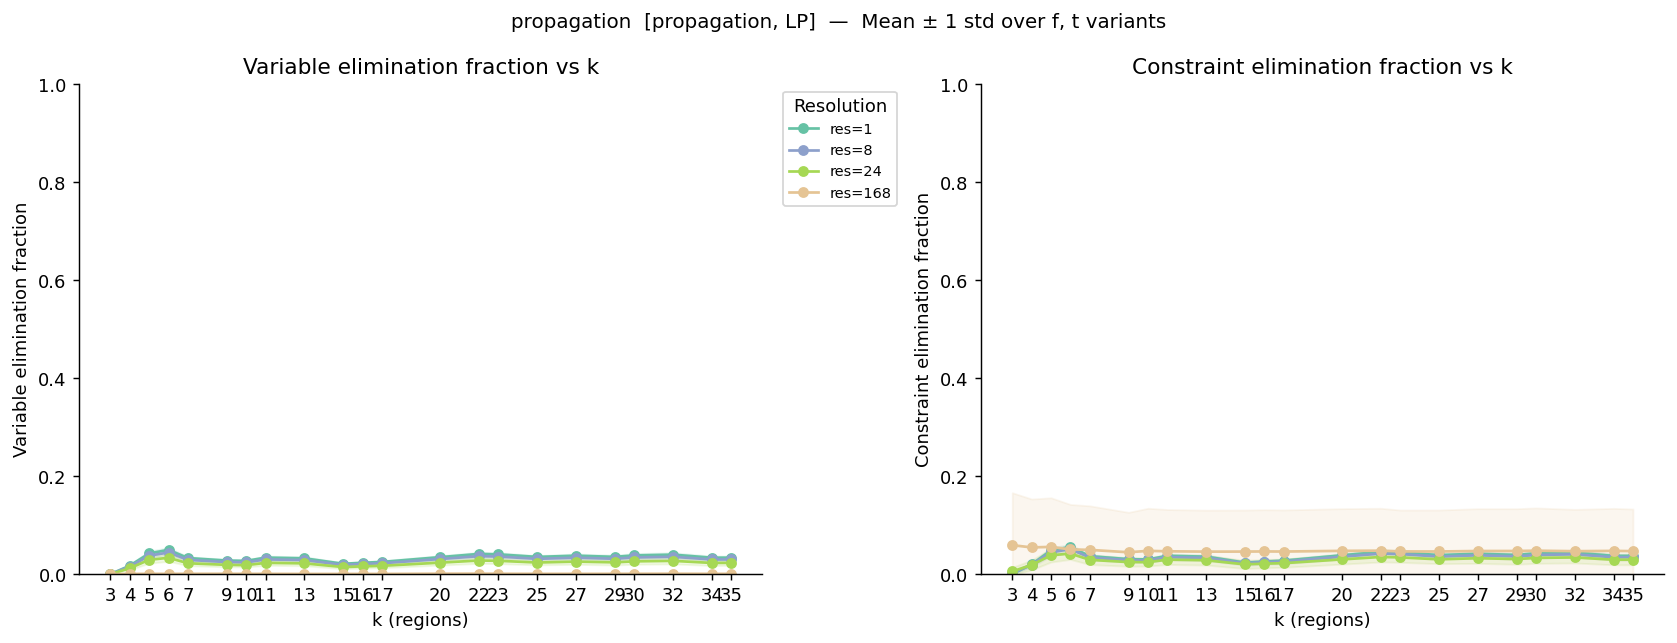

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, label in [
    (axes[0], "del_vars_frac", "Variable elimination fraction"),
    (axes[1], "del_rows_frac", "Constraint elimination fraction"),
]:
    for res in ress:
        grp   = df[df["res"] == res].groupby("k")[col]
        means = grp.mean().reindex(ks)
        stds  = grp.std().reindex(ks)
        ax.plot(means.index, means.values, color=r_colors[res],
                marker="o", markersize=5, label=f"res={res}")
        ax.fill_between(means.index, means - stds, means + stds,
                        color=r_colors[res], alpha=0.15)
    ax.set_xlabel("k (regions)")
    ax.set_ylabel(label)
    ax.set_title(label + " vs k")
    ax.set_xticks(ks)
    ax.set_ylim(0, 1)

axes[0].legend(title="Resolution", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.suptitle(f"{PRESOLVER}{LABEL}  —  Mean ± 1 std over f, t variants", fontsize=11)
fig.tight_layout()
plt.show()

## 3 · Presolve reduction distributions by k

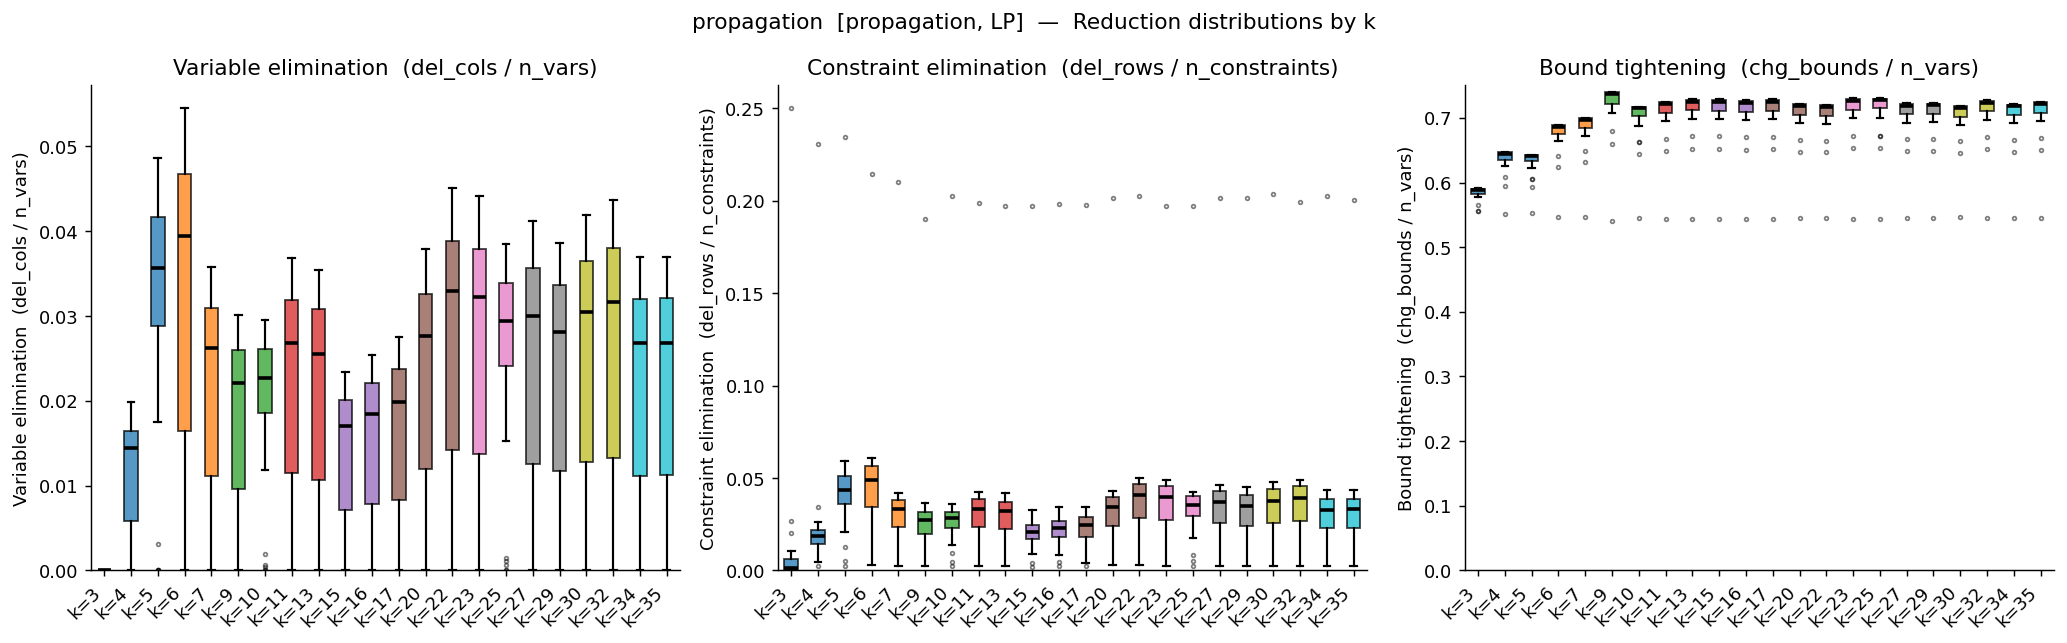

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

panels = [
    ("del_vars_frac",   "Variable elimination  (del_cols / n_vars)"),
    ("del_rows_frac",   "Constraint elimination  (del_rows / n_constraints)"),
    ("chg_bounds_frac", "Bound tightening  (chg_bounds / n_vars)"),
]

for ax, (col, label) in zip(axes, panels):
    data_by_k = [df[df["k"] == k][col].values for k in ks]
    bp = ax.boxplot(data_by_k, patch_artist=True,
                    medianprops=dict(color="black", lw=2),
                    whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2),
                    flierprops=dict(marker=".", markersize=4, alpha=0.5))
    for patch, k in zip(bp["boxes"], ks):
        patch.set_facecolor(k_colors[k])
        patch.set_alpha(0.75)
    ax.set_xticks(range(1, len(ks) + 1))
    ax.set_xticklabels([f"k={k}" for k in ks], rotation=45, ha="right")
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.set_ylim(0, None)

fig.suptitle(f"{PRESOLVER}{LABEL}  —  Reduction distributions by k", fontsize=12)
fig.tight_layout()
plt.show()

## 4 · Variable vs constraint elimination (paired scatter)

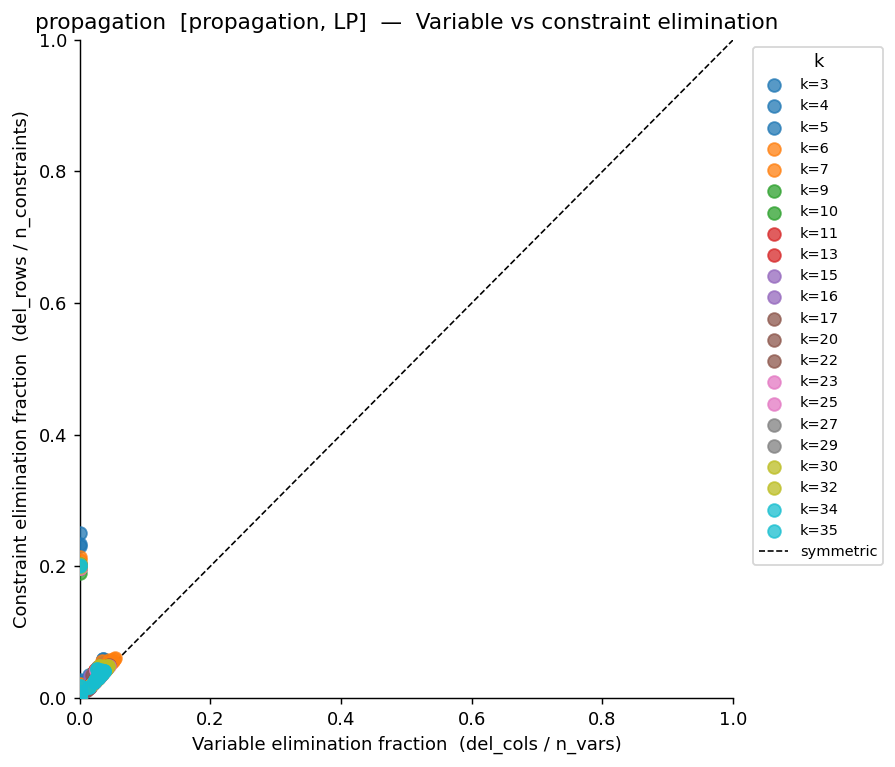

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))

for k in ks:
    sub = df[df["k"] == k]
    ax.scatter(sub["del_vars_frac"], sub["del_rows_frac"],
               color=k_colors[k], label=f"k={k}", alpha=0.75, s=50, zorder=3)

ax.plot([0, 1], [0, 1], "k--", lw=0.9, label="symmetric")
ax.set_xlabel("Variable elimination fraction  (del_cols / n_vars)")
ax.set_ylabel("Constraint elimination fraction  (del_rows / n_constraints)")
ax.set_title(f"{PRESOLVER}{LABEL}  —  Variable vs constraint elimination")
ax.legend(title="k", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
fig.tight_layout()
plt.show()

## 5 · Soft presolving actions — bound tightening and coefficient changes

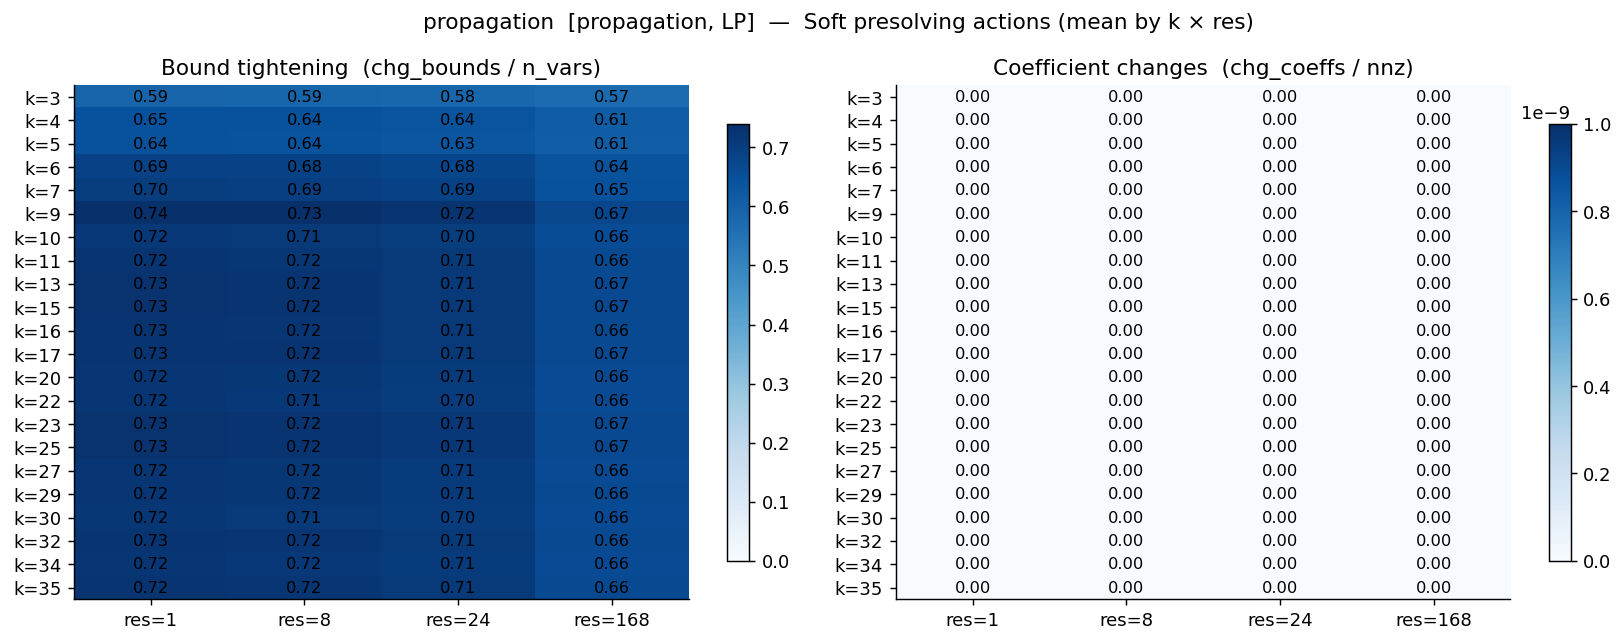

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in [
    (axes[0], "chg_bounds_frac", "Bound tightening  (chg_bounds / n_vars)"),
    (axes[1], "chg_coeffs_frac", "Coefficient changes  (chg_coeffs / nnz)"),
]:
    pivot = df.groupby(["k", "res"])[col].mean().unstack("res")
    vmax  = max(float(pivot.values.max()), 1e-9)
    im = ax.imshow(pivot.values, cmap="Blues", vmin=0, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"res={r}" for r in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"k={k}" for k in pivot.index])
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            ax.text(j, i, f"{pivot.values[i, j]:.2f}",
                    ha="center", va="center", fontsize=9)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.85)

fig.suptitle(f"{PRESOLVER}{LABEL}  —  Soft presolving actions (mean by k × res)", fontsize=12)
fig.tight_layout()
plt.show()

## 6 · Round-by-round cumulative reduction

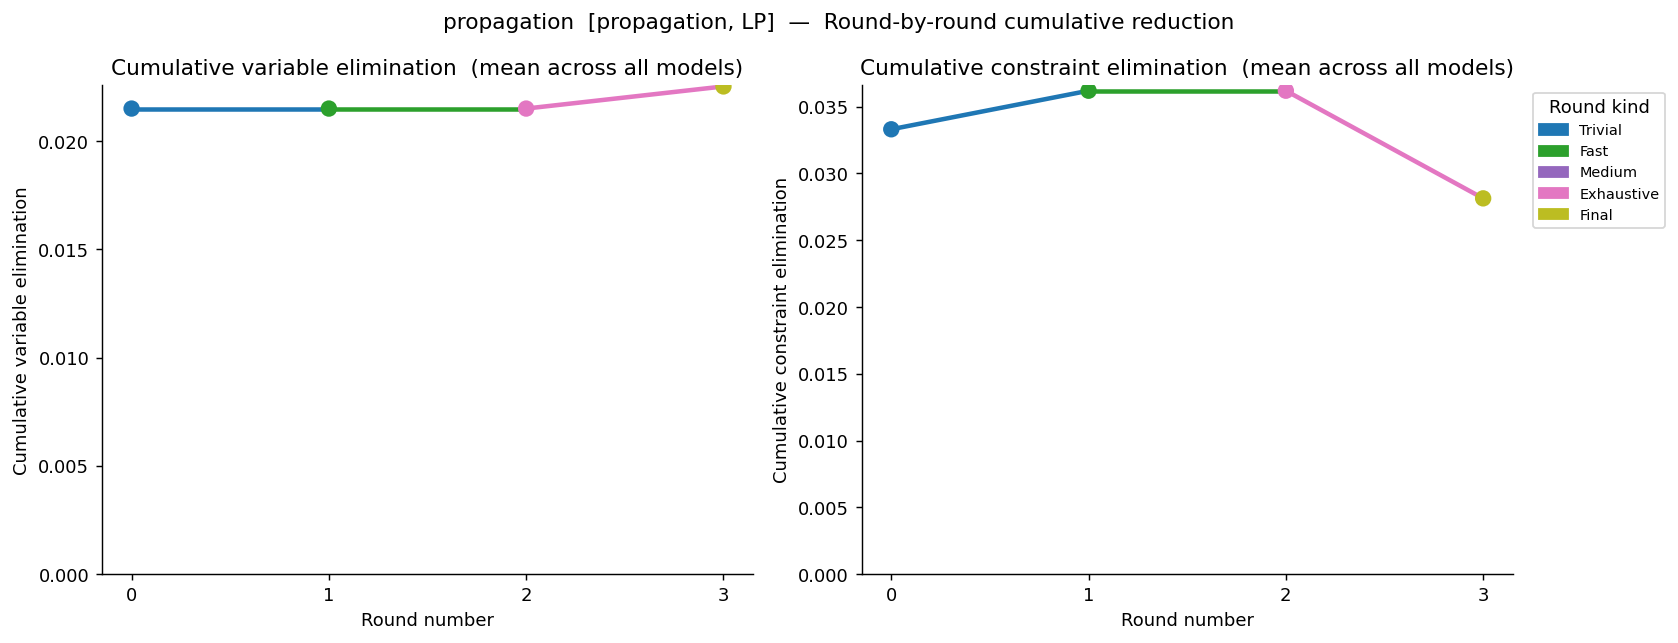

In [9]:
cum_rows = []
for _, row in df.iterrows():
    cum_c, cum_r = 0, 0
    for r in sorted(row["rounds"], key=lambda r: r["number"]):
        cum_c += r["delta"]["del_cols"]
        cum_r += r["delta"]["del_rows"]
        cum_rows.append({
            "round_num": r["number"],
            "kind": r["kind"],
            "cum_del_vars_frac": cum_c / row["n_vars"]        if row["n_vars"]        else 0,
            "cum_del_rows_frac": cum_r / row["n_constraints"] if row["n_constraints"] else 0,
        })

rdf = pd.DataFrame(cum_rows)
mean_by_rnd = rdf.groupby("round_num")[["cum_del_vars_frac", "cum_del_rows_frac"]].mean()
modal_kind  = rdf.groupby("round_num")["kind"].agg(lambda x: x.mode()[0])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, label in [
    (axes[0], "cum_del_vars_frac", "Cumulative variable elimination"),
    (axes[1], "cum_del_rows_frac", "Cumulative constraint elimination"),
]:
    xs = mean_by_rnd.index.tolist()
    ys = mean_by_rnd[col].tolist()
    for i in range(len(xs) - 1):
        c = kind_colors.get(modal_kind[xs[i]], "grey")
        ax.plot([xs[i], xs[i + 1]], [ys[i], ys[i + 1]], color=c, lw=2.5)
    pt_colors = [kind_colors.get(modal_kind[r], "grey") for r in xs]
    ax.scatter(xs, ys, c=pt_colors, zorder=5, s=65)
    ax.set_xlabel("Round number")
    ax.set_ylabel(label)
    ax.set_title(label + "  (mean across all models)")
    ax.set_xticks(xs)
    ax.set_ylim(0, None)

patches = [mpatches.Patch(color=kind_colors[k], label=k) for k in KIND_ORDER]
axes[1].legend(handles=patches, title="Round kind",
               bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.suptitle(f"{PRESOLVER}{LABEL}  —  Round-by-round cumulative reduction", fontsize=12)
fig.tight_layout()
plt.show()

## 7 · Round-kind share of transformations applied, by k

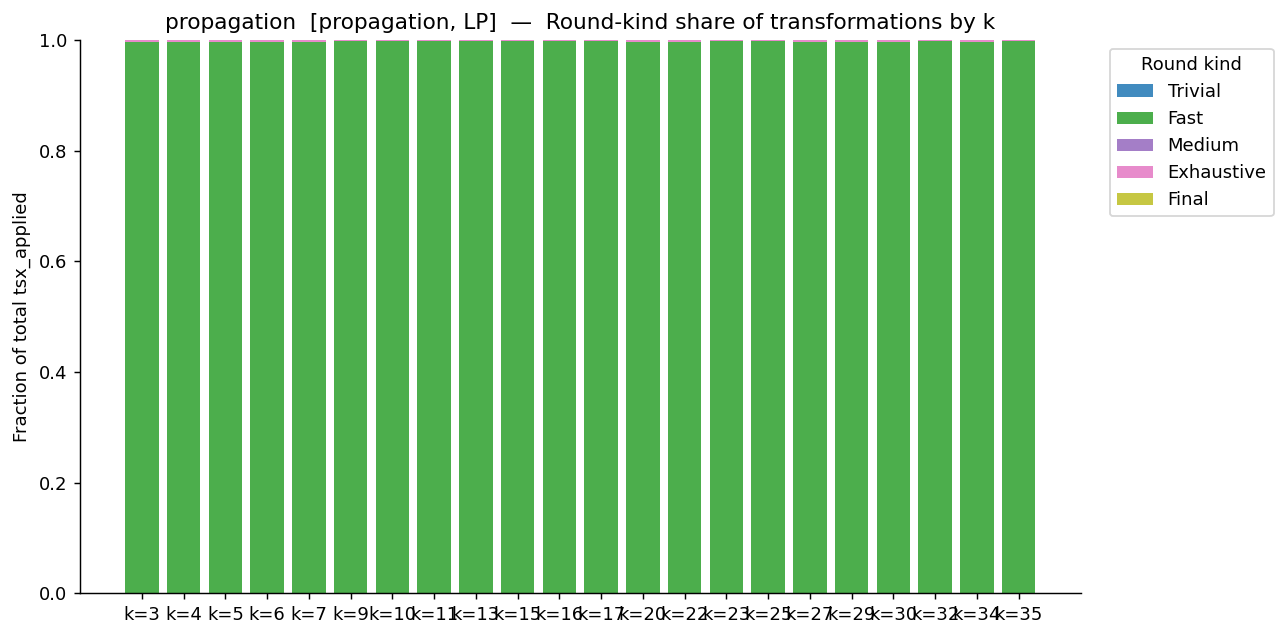

In [10]:
kind_rows = []
for _, row in df.iterrows():
    kind_totals = defaultdict(int)
    for r in row["rounds"]:
        kind_totals[r["kind"]] += r["delta"]["tsx_applied"]
    total = sum(kind_totals.values()) or 1
    kind_rows.append({"k": row["k"],
                      **{kd: kind_totals[kd] / total for kd in KIND_ORDER}})

kdf = pd.DataFrame(kind_rows).groupby("k")[KIND_ORDER].mean()

fig, ax = plt.subplots(figsize=(10, 5))
xs     = np.arange(len(ks))
bottom = np.zeros(len(ks))
for kind in KIND_ORDER:
    vals = kdf.reindex(ks)[kind].fillna(0).values
    ax.bar(xs, vals, bottom=bottom, color=kind_colors[kind], label=kind, alpha=0.85)
    bottom += vals

ax.set_xticks(xs)
ax.set_xticklabels([f"k={k}" for k in ks])
ax.set_ylabel("Fraction of total tsx_applied")
ax.set_title(f"{PRESOLVER}{LABEL}  —  Round-kind share of transformations by k")
ax.legend(title="Round kind", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_ylim(0, 1)
fig.tight_layout()
plt.show()

## 8 · Problem size vs reduction rate

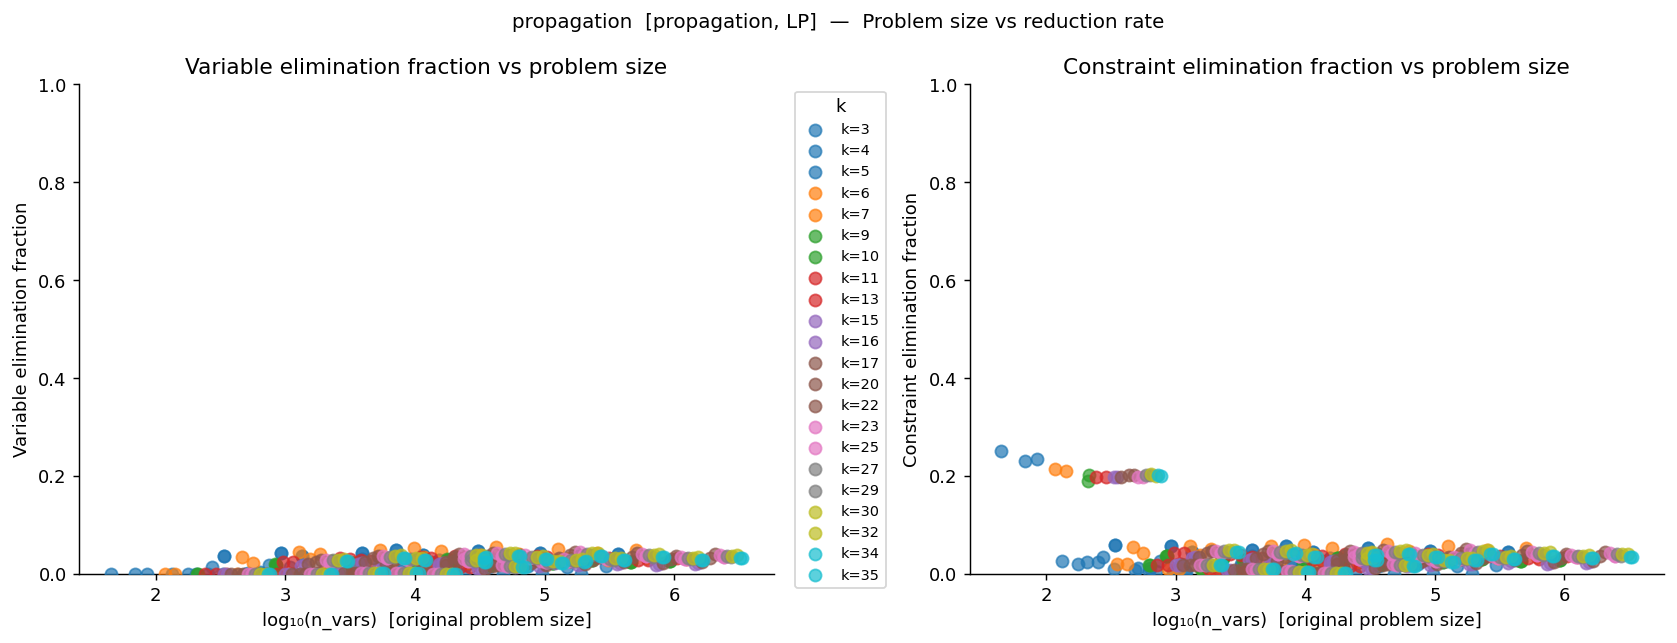

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, label in [
    (axes[0], "del_vars_frac", "Variable elimination fraction"),
    (axes[1], "del_rows_frac", "Constraint elimination fraction"),
]:
    for k in ks:
        sub = df[df["k"] == k]
        ax.scatter(np.log10(sub["n_vars"].clip(lower=1)), sub[col],
                   color=k_colors[k], label=f"k={k}", alpha=0.7, s=45, zorder=3)
    ax.set_xlabel("log₁₀(n_vars)  [original problem size]")
    ax.set_ylabel(label)
    ax.set_title(label + " vs problem size")
    ax.set_ylim(0, 1)

axes[0].legend(title="k", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.suptitle(f"{PRESOLVER}{LABEL}  —  Problem size vs reduction rate", fontsize=11)
fig.tight_layout()
plt.show()